In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [2]:
from unsloth import FastVisionModel
import torch

fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit",
]

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Llama-3.2-11B-Vision-Instruct",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.1.3: Fast Mllama patching. Transformers: 4.56.2.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.94G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

In [3]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

Unsloth: Making `model.base_model.model.model.vision_model.transformer` require gradients


In [4]:
from datasets import load_dataset

dataset = load_dataset("Raja6922/navarasa_Balanced", split="train")

README.md:   0%|          | 0.00/473 [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/420M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/417M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/425M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/424M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/182M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6951 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/773 [00:00<?, ? examples/s]

In [5]:
dataset

Dataset({
    features: ['image', 'navarasa', 'text'],
    num_rows: 6951
})

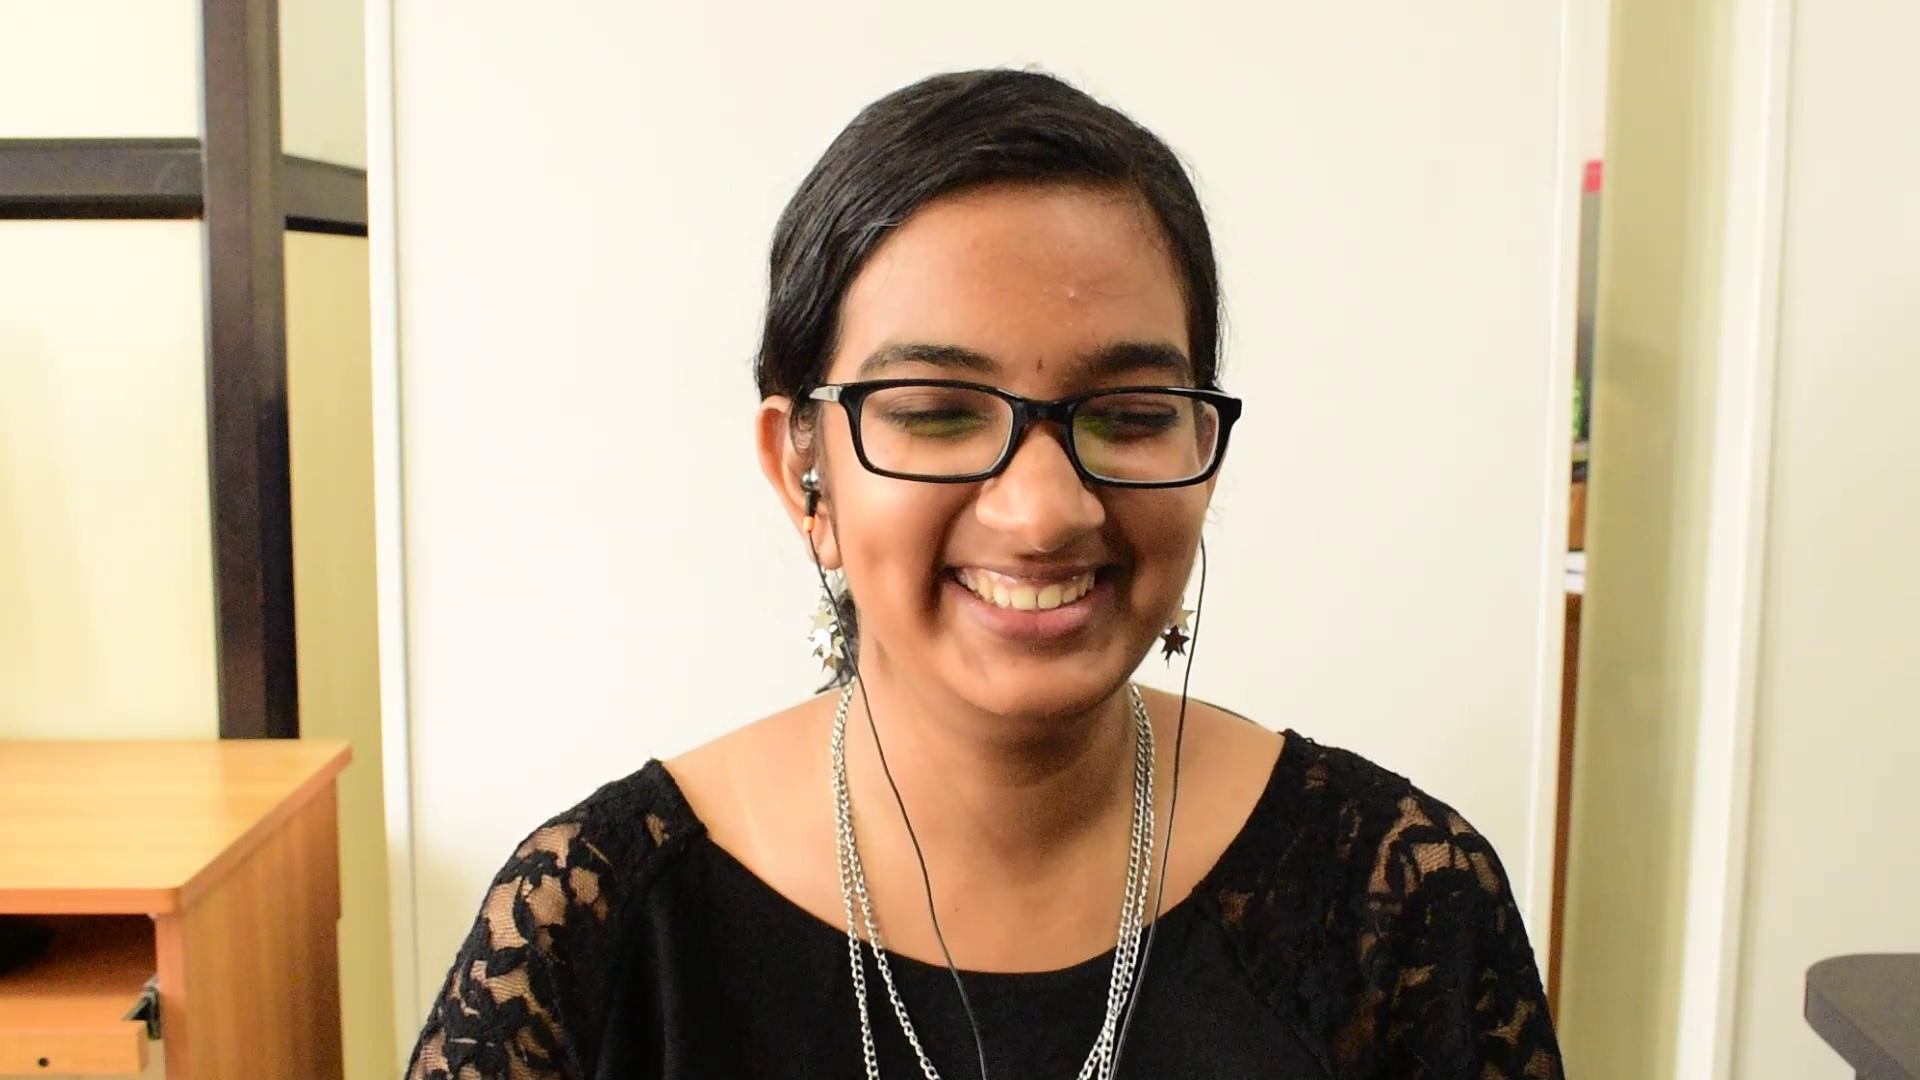

In [6]:
dataset[345]["image"]

In [8]:
dataset[345]["text"]

'The subject exhibiting Hasya, with a woman wearing glasses and a black top smiles , conveying the emotional essence of Hasya.'

In [11]:
instruction = "You are an expert in emotion recognition. Describe accurately what emotion you see in this image."

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["text"]} ]
        },
    ]
    return { "messages" : conversation }
pass

In [12]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

In [13]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'You are an expert in emotion recognition. Describe accurately what emotion you see in this image.'},
    {'type': 'image',
     'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1920x1080>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': 'The subject exhibiting Hasya, with a woman wearing glasses and a black top smiles , conveying the emotional essence of Hasya.'}]}]}

In [33]:
FastVisionModel.for_inference(model)

image = dataset[345]["image"]
instruction = "You are an expert in emotion recognition. Describe accurately what emotion you see in this image in the context of navarasa."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

The subject exhibiting Raudra, with a young woman wearing glasses sits at a desk, conveying the emotional essence of Raudra.<|eot_id|>


In [26]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        #max_steps = 30,
        num_train_epochs = 1,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",

        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

In [27]:
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA A100-SXM4-80GB. Max memory = 79.318 GB.
10.078 GB of memory reserved.


In [28]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,951 | Num Epochs = 1 | Total steps = 869
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 67,174,400 of 10,737,395,235 (0.63% trained)


Step,Training Loss
1,0.100100
2,0.092800
3,0.108100
4,0.104300
5,0.068600
6,0.061500
7,0.104100
8,0.106200
9,0.115000
10,0.131000


In [29]:
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

4836.3262 seconds used for training.
80.61 minutes used for training.
Peak reserved memory = 10.447 GB.
Peak reserved memory for training = 0.369 GB.
Peak reserved memory % of max memory = 13.171 %.
Peak reserved memory for training % of max memory = 0.465 %.


In [30]:
FastVisionModel.for_inference(model)

image = dataset[345]["image"]
instruction = "You are an expert in emotion recognition. Describe accurately what emotion you see in this image in the context of navarasa."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

The subject exhibiting Hasya, with a young woman wearing glasses smiles at the camera, conveying the emotional essence of Hasya.<|eot_id|>


In [ ]:
model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")
model.push_to_hub("Raja6922/Llama3.2_11B", token = "token")
tokenizer.push_to_hub("Raja6922/Llama3.2_11B", token = "token")

README.md:   0%|          | 0.00/600 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          |  131kB /  269MB            

Saved model to https://huggingface.co/Raja6922/Llama3.2_11B


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp6mo681ty/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            